In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [80]:
import sklearn
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,precision_score,classification_report,recall_score,f1_score,confusion_matrix)

In [81]:
print("==============Version Check=============")
print("Numpy       :",np.__version__)
print("Pandas      :",pd.__version__)
print("Matplotlib  :",plt.matplotlib.__version__)
print("Seaborn     :",sns.__version__)
print("Sickit-Learn:",sklearn.__version__)
print("===========Libraries Installed==========")

==============Version Check=============
Numpy       : 2.0.2
Pandas      : 2.2.2
Matplotlib  : 3.10.0
Seaborn     : 0.13.2
Sickit-Learn: 1.6.1
===========Libraries Installed==========


## **EDA**

In [82]:
df = pd.read_csv("drug200.csv")
print("==================== First 5 Rows ====================")
display(df.head())
print("==================== last 5 Rows =====================")
display(df.tail())

==================== First 5 Rows ====================


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


==================== last 5 Rows =====================


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX
199,40,F,LOW,NORMAL,11.349,drugX


In [83]:
print("Rows    :",df.shape[0],"\nColumns :",df.shape[1])

Rows    : 200 
Columns : 6


In [84]:
print("================ Data Info ================\n")
df.info()
print("============================================")

================ Data Info ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [85]:
print(df.isnull().sum())

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


In [86]:
print("========================Statistical Summary=========================")
df.describe(include='all')

========================Statistical Summary=========================


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
count,200.000000,200,200,200,200.000000,200
unique,NaN,2,3,2,NaN,5
top,NaN,M,HIGH,HIGH,NaN,DrugY
freq,NaN,104,77,103,NaN,91
mean,44.315000,NaN,NaN,NaN,16.084485,NaN
std,16.544315,NaN,NaN,NaN,7.223956,NaN
min,15.000000,NaN,NaN,NaN,6.269000,NaN
25%,31.000000,NaN,NaN,NaN,10.445500,NaN
50%,45.000000,NaN,NaN,NaN,13.936500,NaN
75%,58.000000,NaN,NaN,NaN,19.380000,NaN


## **Visualization**

/tmp/ipykernel_1583/1031726341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Drug',data= df,palette='Set2',order=order)


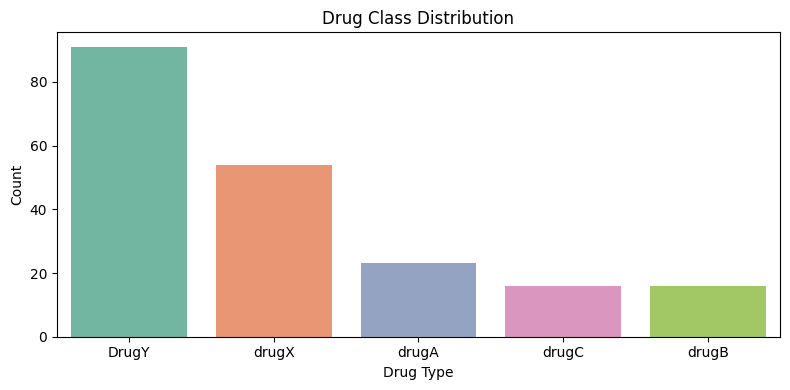

In [87]:
plt.figure(figsize=(8,4))
order = df['Drug'].value_counts().index
ax = sns.countplot(x='Drug',data= df,palette='Set2',order=order)


plt.title("Drug Class Distribution")
plt.xlabel("Drug Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

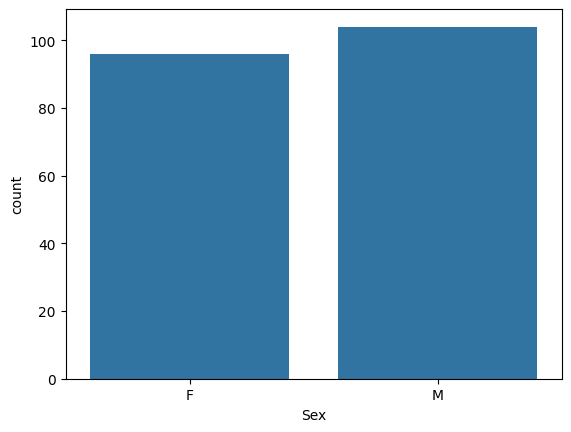

In [88]:
sns.countplot(x='Sex', data=df)
plt.show()

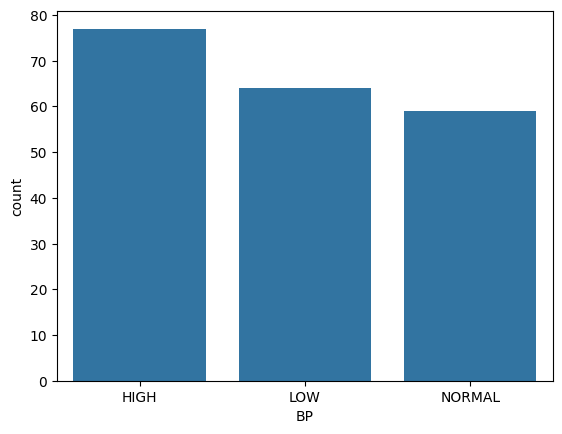

In [89]:
sns.countplot(x='BP', data=df)
plt.show()

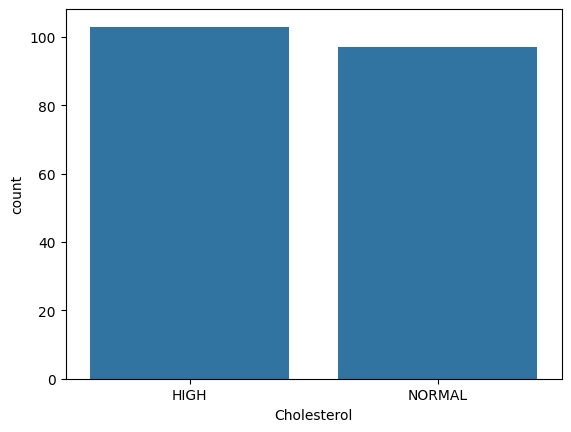

In [90]:
sns.countplot(x='Cholesterol', data=df)
plt.show()

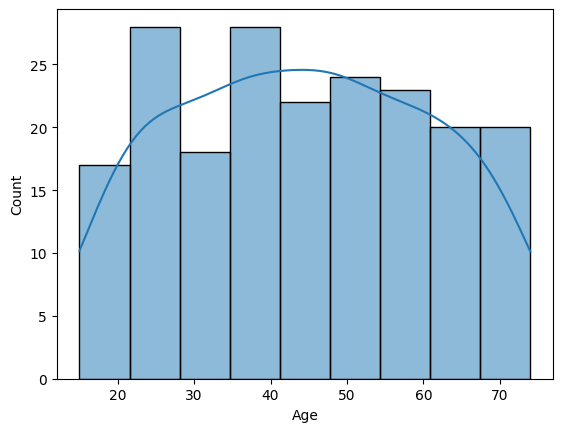

In [91]:
sns.histplot(df['Age'], kde=True)
plt.show()

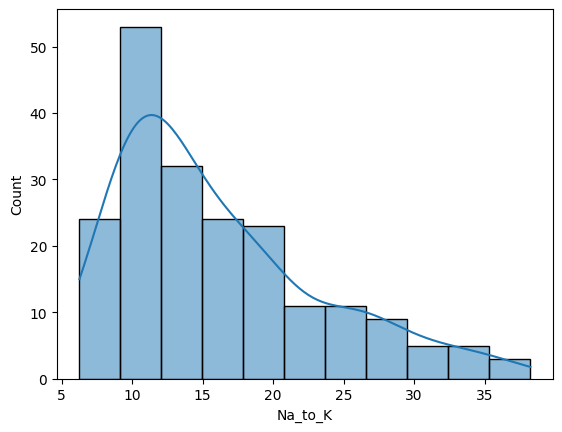

In [92]:
sns.histplot(df['Na_to_K'], kde=True)
plt.show()

## **DATA PREPROCCESSING**

In [93]:
duplicates = df.duplicated().sum()
print("Dupliactes Row :",duplicates)
df = df.drop_duplicates()
print("Shape after clean up :",df.shape)

Dupliactes Row : 0
Shape after clean up : (200, 6)


In [94]:
numeric_cols = df.select_dtypes(include=['number']).columns
missing_num = df[numeric_cols].isna().sum()
print("Missing Numeric Values:")
print(missing_num[missing_num>0]if missing_num.sum()>0 else "No missing Values")
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


Missing Numeric Values:
No missing Values


In [95]:
cat_cols = df.select_dtypes(exclude='number').columns
missing_cat = df[cat_cols].isna().sum()
print("Missing Categorical Values:")
print(missing_cat[missing_cat>0]if missing_cat.sum()>0 else "No Missing Categories")
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

Missing Categorical Values:
No Missing Categories


In [96]:
X = df.drop('Drug', axis=1)
y = df['Drug']

In [97]:
# Label Encoders
le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_cholesterol = LabelEncoder()
le_drug = LabelEncoder()

# Fit encoders
le_sex.fit(X['Sex'])
le_bp.fit(X['BP'])
le_cholesterol.fit(X['Cholesterol'])

# Encode target
y = le_drug.fit_transform(y)

print("Label Encoders initialized and fitted successfully.")

print("\nDrug Label Encoding Mapping:")
for i, drug in enumerate(le_drug.classes_):
    print(f"{i} -> {drug}")

Label Encoders initialized and fitted successfully.

Drug Label Encoding Mapping:
0 -> DrugY
1 -> drugA
2 -> drugB
3 -> drugC
4 -> drugX


In [98]:
print("Features Shape    :",X.shape)
print("Targret Shape     :",y.shape)
print("Target Unique     :",len(np.unique(y)))
print("Target Value Counts:")
print(pd.Series(y).value_counts().to_string())

Features Shape    : (200, 5)
Targret Shape     : (200,)
Target Unique     : 5
Target Value Counts:
0    91
4    54
1    23
3    16
2    16


In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [100]:
# Apply Label Encoding to categorical columns in X_train and X_test
X_train['Sex'] = le_sex.transform(X_train['Sex'])
X_test['Sex'] = le_sex.transform(X_test['Sex'])

X_train['BP'] = le_bp.transform(X_train['BP'])
X_test['BP'] = le_bp.transform(X_test['BP'])

X_train['Cholesterol'] = le_cholesterol.transform(X_train['Cholesterol'])
X_test['Cholesterol'] = le_cholesterol.transform(X_test['Cholesterol'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [101]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nScaled Training Data:\n")
print(X_train_scaled[:5])

X_train shape: (160, 5)
X_test shape: (40, 5)

Scaled Training Data:

[[-0.83405574 -1.03823026  0.0820827   1.1055416  -0.74045911]
 [ 0.41196591  0.96317747  1.27601281 -0.90453403 -0.87126694]
 [-0.39794817 -1.03823026  1.27601281  1.1055416  -0.89684776]
 [-0.77175466 -1.03823026  0.0820827  -0.90453403  2.39090899]
 [-0.70945358  0.96317747  1.27601281 -0.90453403  0.86573941]]


## **MODEL TRAINING**

In [102]:
# Instantiate Logistic Regression model
log_reg_model = LogisticRegression(
    random_state=42,
    solver='lbfgs',
    max_iter=1000
)

# Fit the model on the scaled training data
log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [103]:
import os
# Instantiate KNN model
knn_model = KNeighborsClassifier()

# Fit the model on the scaled training data
knn_model.fit(X_train_scaled, y_train)
import joblib

# Create the 'models' directory if it doesn't exist
output_dir = '../models/'
os.makedirs(output_dir, exist_ok=True)

# KNN model save
# Logistic Regression model save
joblib.dump(log_reg_model, os.path.join(output_dir, "logistic_model.pkl"))
joblib.dump(knn_model, os.path.join(output_dir, "knn_model.pkl"))



print("K-Nearest Neighbors model trained successfully.")

K-Nearest Neighbors model trained successfully.


In [104]:
import joblib

joblib.dump(knn_model, "knn_model.pkl")
joblib.dump(log_reg_model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Files saved successfully")

Files saved successfully


## **PREDICTION**

In [105]:
# Predictions from Logistic Regression model
y_pred_lr = log_reg_model.predict(X_test_scaled)
print("Predictions from Logistic Regression generated.")

Predictions from Logistic Regression generated.


In [106]:
# Predictions from K-Nearest Neighbors model
y_pred_knn = knn_model.predict(X_test_scaled)
print("Predictions from K-Nearest Neighbors generated.")

Predictions from K-Nearest Neighbors generated.


In [107]:
print("===== LOGISTIC REGRESSION =====")

# Accuracy Score

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_lr)*100)

# Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Precision

print("\nPrecision:")
print(precision_score(y_test, y_pred_lr, average='weighted')*100)


===== LOGISTIC REGRESSION =====
Accuracy Score:
92.5

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         3
           3       1.00      0.80      0.89         5
           4       1.00      0.91      0.95        11

    accuracy                           0.93        40
   macro avg       0.95      0.93      0.93        40
weighted avg       0.93      0.93      0.93        40


Precision:
93.16964285714285


In [108]:
print("\n===== KNN =====")

# Accuracy Score

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_knn)*100,"%")

# Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Precision

print("\nPrecision:")
print(precision_score(y_test, y_pred_knn, average='weighted')*100)


===== KNN =====
Accuracy Score:
87.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         3
           3       1.00      0.60      0.75         5
           4       0.83      0.91      0.87        11

    accuracy                           0.88        40
   macro avg       0.91      0.88      0.88        40
weighted avg       0.88      0.88      0.87        40


Precision:
88.27380952380952


## **CONFUSION MATRIX**

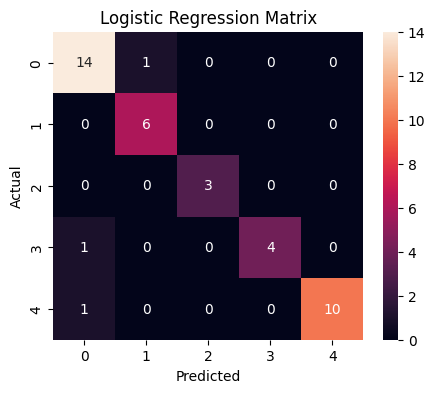

In [109]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

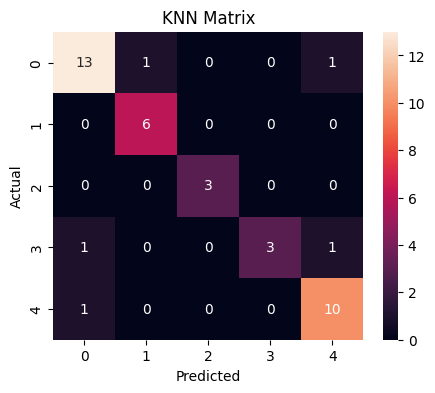

In [110]:
# KNN Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("KNN Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **INPUT**

In [ ]:
age = int(input("Enter Age: "))

while True:
    sex = input("Enter Sex (M/F): ").upper()
    if sex in ['M', 'F']:
        break
    print("Invalid input! Enter M or F.")

while True:
    bp = input("Enter BP (HIGH/NORMAL/LOW): ").upper()
    if bp in ['HIGH', 'NORMAL', 'LOW']:
        break
    print("Invalid input!")

while True:
    chol = input("Enter Cholesterol (HIGH/NORMAL): ").upper()
    if chol in ['HIGH', 'NORMAL']:
        break
    print("Invalid input!")

na_to_k = float(input("Enter Na_to_K: "))

sex_encoded = le_sex.transform([sex])[0]
bp_encoded = le_bp.transform([bp])[0]
chol_encoded = le_cholesterol.transform([chol])[0]

In [ ]:
new_data = np.array([[age, sex_encoded, bp_encoded, chol_encoded, na_to_k]])

# Scale the new data using the fitted scaler
new_data_scaled = scaler.transform(new_data)

# Predict using Logistic Regression
prediction_lr_encoded = log_reg_model.predict(new_data_scaled)
prediction_lr_drug = le_drug.inverse_transform(prediction_lr_encoded)

# Predict using KNN
prediction_knn_encoded = knn_model.predict(new_data_scaled)
prediction_knn_drug = le_drug.inverse_transform(prediction_knn_encoded)

print(f"\nPredicted Drug (Logistic Regression): {prediction_lr_drug[0]}")
print(f"Predicted Drug (KNN): {prediction_knn_drug[0]}")

## **CONCLUSION**

In [ ]:
# Objective Achieved

print("Objective Achieved:")
print("The Drug200 dataset was successfully analyzed and machine learning models were used to predict suitable drugs.")


# Calculate accuracy scores using the previously generated predictions
lr_accuracy = accuracy_score(y_test, y_pred_lr)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("\nModel Performance:\n")
print("Logistic Regression Accuracy:\n", lr_accuracy*100,"%")
print("KNN Accuracy:\n", knn_accuracy*100,"%")

